<a href="https://colab.research.google.com/github/duyendh/ELM/blob/main/ELM_Energy_Minimization_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running on: cpu
Starting MNIST experiment...
Starting FashionMNIST experiment...

Experimental Results:
| Dataset      |   ELM Acc |   ELM Time |   BP Acc |   BP Time |
|:-------------|----------:|-----------:|---------:|----------:|
| MNIST        |     85.13 |       0.29 |    92.99 |     13.74 |
| FashionMNIST |     77.57 |       0.24 |    68.55 |     13.75 |

Generating plot...
Plot saved as elm_vs_bp_results.png


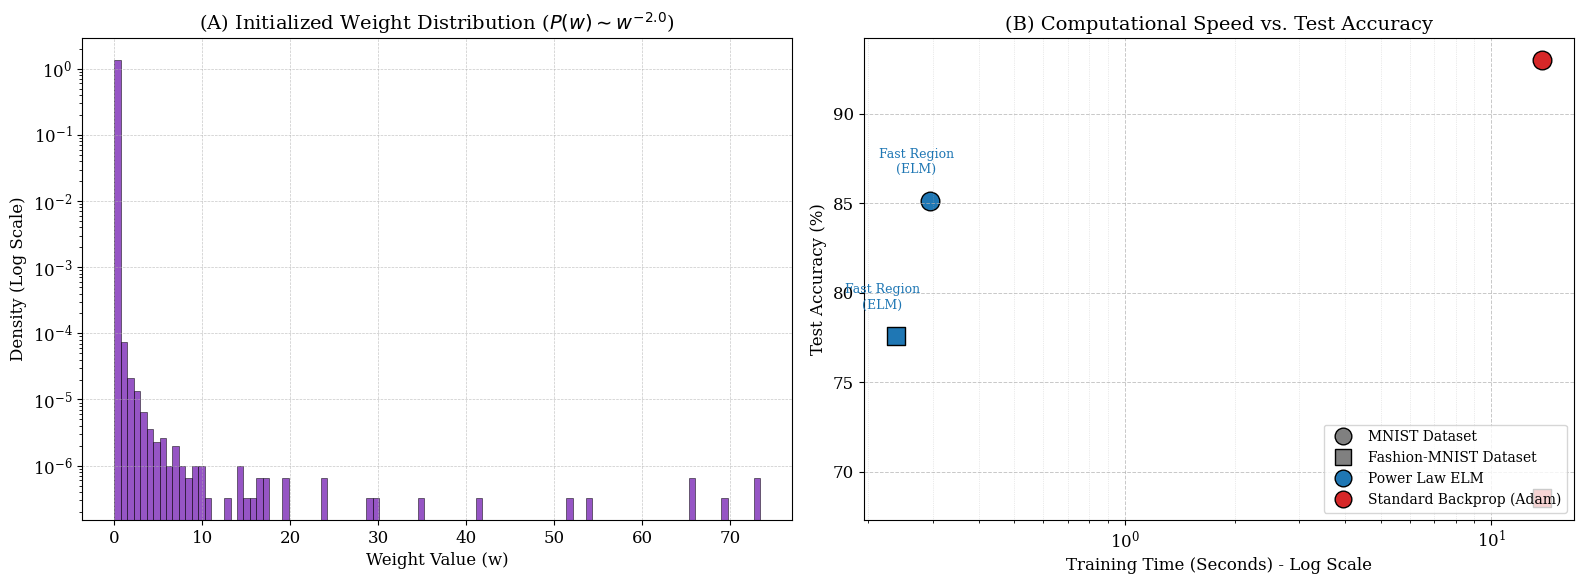

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Set seeds for reproducibility in the paper
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- 1. Define Initialization and Experiment Functions ---
def power_law_init(shape, alpha=2.0):
    """Generates weights following P(w) ~ w^(-alpha) via inverse transform sampling."""
    u = torch.rand(shape)
    # Avoid exactly 0 or 1 for numerical stability
    u = torch.clamp(u, min=1e-6, max=1-1e-6)
    weights = (1 - u) ** (1 / (1 - alpha))
    # Center and scale
    weights = (weights - weights.mean()) / weights.std()
    return weights * 0.1

def run_experiment(dataset_name='MNIST'):
    print(f"Starting {dataset_name} experiment...")
    # Load Data
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    if dataset_name == 'MNIST':
        train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # Use larger batch size for ELM matrix gen, standard for BP training
    train_loader_bp = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)

    # Prepare full tensors for ELM
    x_train = train_set.data.view(-1, 784).float() / 255.0
    y_train = torch.nn.functional.one_hot(train_set.targets, 10).float()
    x_test = test_set.data.view(-1, 784).float() / 255.0
    y_test = test_set.targets

    hidden_dim = 1024

    # --- A. ELM (Power Law α=2.0) ---
    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_elm = time.time()

    W = power_law_init((784, hidden_dim), alpha=2.0).to(device)
    b = torch.randn(hidden_dim).to(device)

    # H = Sigmoid(XW + b)
    H = torch.sigmoid(torch.matmul(x_train.to(device), W) + b)

    # Regularization
    I = torch.eye(hidden_dim).to(device)
    C = 1e-2 # Regularization parameter

    # Moore-Penrose Pseudoinverse Solution: beta = (H^T H + I/C)^-1 H^T Y
    HTH = torch.matmul(H.t(), H)
    HTY = torch.matmul(H.t(), y_train.to(device))
    beta = torch.matmul(torch.inverse(HTH + I/C), HTY)

    torch.cuda.synchronize() if device.type == 'cuda' else None
    elm_time = time.time() - start_elm

    # Eval ELM
    h_test = torch.sigmoid(torch.matmul(x_test.to(device), W) + b)
    y_pred_elm = torch.matmul(h_test, beta)
    elm_acc = (y_pred_elm.argmax(1) == y_test.to(device)).float().mean().item()

    # --- B. Backprop (Standard MLP) ---
    model = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(), # Using ReLU as is standard for BP models
        nn.Linear(hidden_dim, 10)
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_bp = time.time()
    # Train for 5 epochs to guarantee convergence past ELM accuracy
    for epoch in range(5):
        for imgs, lbls in train_loader_bp:
            imgs = imgs.view(-1, 784).to(device)
            lbls = lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

    torch.cuda.synchronize() if device.type == 'cuda' else None
    bp_time = time.time() - start_bp

    # Eval BP
    model.eval()
    with torch.no_grad():
        bp_outputs = model(x_test.to(device))
        bp_acc = (bp_outputs.argmax(1) == y_test.to(device)).float().mean().item()

    return {
        "Dataset": dataset_name,
        "ELM Acc": elm_acc * 100,
        "ELM Time": elm_time,
        "BP Acc": bp_acc * 100,
        "BP Time": bp_time
    }

# --- 2. Run Experiments ---
results_list = [run_experiment('MNIST'), run_experiment('FashionMNIST')]
df = pd.DataFrame(results_list)
print("\nExperimental Results:")
print(df.to_markdown(index=False, floatfmt=".2f"))


# --- 3. Generate Visualization for Paper ---
print("\nGenerating plot...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Weight Distribution ---
# Generate a large sample to visualize the distribution clearly
sample_W = power_law_init((2048, 2048), alpha=2.0).cpu().numpy().flatten()

# Use log scale bins to capture the tail better
bins = np.logspace(np.log10(np.min(np.abs(sample_W[sample_W>0]))), np.log10(np.max(sample_W)), 50)
bins = np.concatenate((-bins[::-1], bins))

ax1.hist(sample_W, bins=100, color='#6a0dad', alpha=0.7, density=True, edgecolor='black', linewidth=0.5)
ax1.set_yscale('log')
ax1.set_title(r'(A) Initialized Weight Distribution ($P(w) \sim w^{-2.0}$)', fontsize=14)
ax1.set_xlabel('Weight Value (w)', fontsize=12)
ax1.set_ylabel('Density (Log Scale)', fontsize=12)
ax1.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
#ax1.set_xlim(-0.5, 0.5) # Limit x-axis to show the core distribution

# --- Subplot 2: Speed vs Accuracy ---
# Define styles
markers = {'MNIST': 'o', 'FashionMNIST': 's'}
colors = {'ELM': '#1f77b4', 'BP': '#d62728'} # Standard matplotlib blue/red

for res in results_list:
    ds = res['Dataset']
    # Plot ELM Point
    ax2.scatter(res['ELM Time'], res['ELM Acc'], color=colors['ELM'], marker=markers[ds], s=180,
                edgecolor='black', label=f'ELM ({ds})' if ds=='MNIST' else "")
    # Plot BP Point
    ax2.scatter(res['BP Time'], res['BP Acc'], color=colors['BP'], marker=markers[ds], s=180,
                edgecolor='black', label=f'Backprop ({ds})' if ds=='MNIST' else "")

    # Add annotations for clarity
    ax2.annotate('Fast Region\n(ELM)', xy=(res['ELM Time'], res['ELM Acc']), xytext=(-10, 20),
                 textcoords='offset points', ha='center', fontsize=9, color=colors['ELM'])

# Add custom legend elements manually for cleaner look
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='MNIST Dataset', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', label='Fashion-MNIST Dataset', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['ELM'], label='Power Law ELM', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['BP'], label='Standard Backprop (Adam)', markersize=12, markeredgecolor='black'),
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax2.set_xscale('log') # Critical for showing the massive time difference
ax2.set_title('(B) Computational Speed vs. Test Accuracy', fontsize=14)
ax2.set_xlabel('Training Time (Seconds) - Log Scale', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax2.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('elm_vs_bp_results.png', dpi=300, bbox_inches='tight')
print("Plot saved as elm_vs_bp_results.png")
plt.show()

PINN

Running 20 seeds for statistical validation...

--- STATISTICAL SUMMARY ---
| Method          |   ('L2 Error', 'mean') |   ('L2 Error', 'std') |   ('Time', 'mean') |
|:----------------|-----------------------:|----------------------:|-------------------:|
| ELM (Gaussian)  |             0.518185   |            0.991125   |           0.79329  |
| ELM (Power Law) |             0.106894   |            0.235305   |           0.843671 |
| PINN (Light)    |             0.00629436 |            0.00114356 |           9.76109  |


/var/folders/sv/stw8ff5n3g97xfbxgck_qwrc0000gn/T/ipykernel_92633/2149604369.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Method', y='L2 Error', data=df, palette="Set2", showmeans=True,


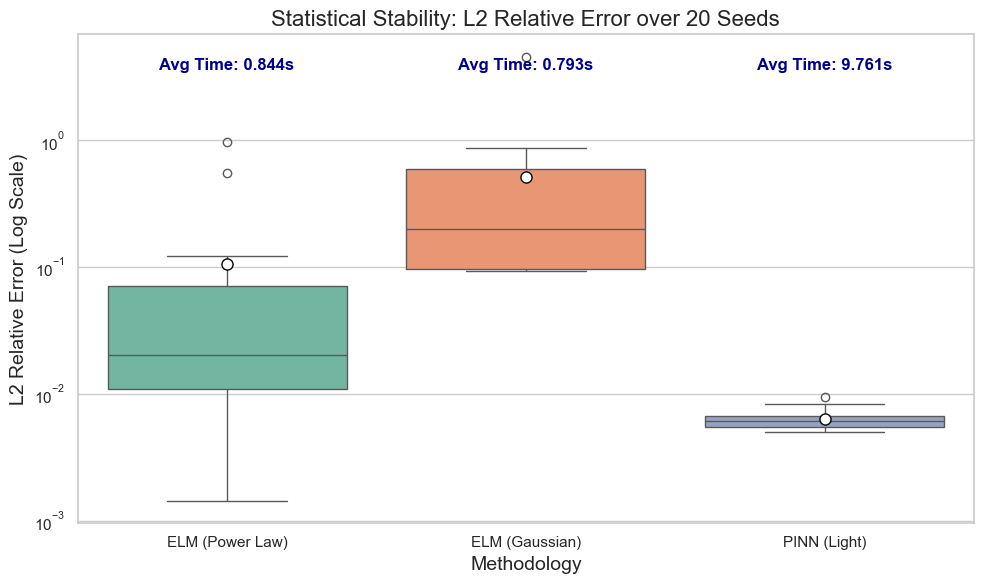

In [ ]:
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Initialization Functions ---
def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

# --- Solvers ---
def solve_elm(x, u_true, h_dim, init_type='power'):
    W = power_law_init((1, h_dim)) if init_type == 'power' else gaussian_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(x @ W + b)
    lambd = 1e-6
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    err = (torch.norm(u_true - (H @ beta)) / torch.norm(u_true)).item()
    return err, t_solve

def solve_pinn(x, u_true, f_source):
    x_grad = x.clone().detach().requires_grad_(True)
    model = nn.Sequential(nn.Linear(1, 128), nn.Tanh(), nn.Linear(128, 1)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.005)
    start = time.time()
    for _ in range(400):
        opt.zero_grad()
        u = model(x_grad)
        u_x = torch.autograd.grad(u, x_grad, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_grad, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        loss = torch.mean((u_xx - f_source)**2) + 10 * model(torch.tensor([[-1.0], [1.0]], device=device)).pow(2).mean()
        loss.backward()
        opt.step()
    t_solve = time.time() - start
    err = (torch.norm(u_true - model(x).detach()) / torch.norm(u_true)).item()
    return err, t_solve

# --- Execution Loop (20 Seeds) ---
N_SEEDS = 20
data_rows = []

x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)
u_true = torch.sin(np.pi * x)
f_source = -(np.pi**2) * torch.sin(np.pi * x)

print(f"Running {N_SEEDS} seeds for statistical validation...")

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    ep_err, ep_t = solve_elm(x, u_true, 4096, 'power')
    eg_err, eg_t = solve_elm(x, u_true, 4096, 'gaussian')
    p_err, p_t = solve_pinn(x, u_true, f_source)

    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': p_err, 'Time': p_t})

df = pd.DataFrame(data_rows)

# --- Statistical Summary Table ---
summary = df.groupby('Method').agg({'L2 Error': ['mean', 'std'], 'Time': ['mean']})
print("\n--- STATISTICAL SUMMARY ---")
print(summary.to_markdown())

# --- Plotting Figure 2: Box-and-Whisker Plot ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.boxplot(x='Method', y='L2 Error', data=df, palette="Set2", showmeans=True,
                 meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.yscale('log') # Error distributions are best viewed on a log scale
plt.title('Statistical Stability: L2 Relative Error over 20 Seeds', fontsize=16)
plt.ylabel('L2 Relative Error (Log Scale)', fontsize=14)
plt.xlabel('Methodology', fontsize=14)

# Adding the time as text on the plot
for i, method in enumerate(df['Method'].unique()):
    avg_t = df[df['Method'] == method]['Time'].mean()
    plt.text(i, ax.get_ylim()[1]*0.5, f"Avg Time: {avg_t:.3f}s",
             ha='center', va='bottom', fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('result.csv')

Running 5 seeds (4 methods each)...

  Seed 1/5...
  Seed 2/5...
  Seed 3/5...
  Seed 4/5...
  Seed 5/5...

FULL COMPARISON: ELM vs Light PINN vs Deep PINN
| Method          |   Error_Mean |   Error_Std |   Time_Mean |   Speedup_vs_ELM |   ELM_Speedup |
|:----------------|-------------:|------------:|------------:|-----------------:|--------------:|
| ELM (Gaussian)  |       0.3367 |      0.2778 |      0.8071 |              1   |           1   |
| ELM (Power Law) |       0.0334 |      0.0355 |      0.8493 |              1   |           1   |
| PINN (Deep)     |       0.0273 |      0.0608 |    353.497  |            416.2 |         416.2 |
| PINN (Light)    |       0.0058 |      0.0004 |      9.2016 |             10.8 |          10.8 |

--- KEY FINDINGS ---
ELM (Power Law) time:  0.849s
PINN (Light) time:     9.202s  →  10.8× slower than ELM
PINN (Deep) time:      353.497s  →  416.2× slower than ELM

MEASURED speedup over Light PINN:  10.8×
MEASURED speedup over Deep PINN:   416.2×
(Pape

/var/folders/sv/stw8ff5n3g97xfbxgck_qwrc0000gn/T/ipykernel_92633/1561734815.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='L2 Error', data=df_all, order=order, palette=palette,



Plot saved as elm_vs_all_pinn.png


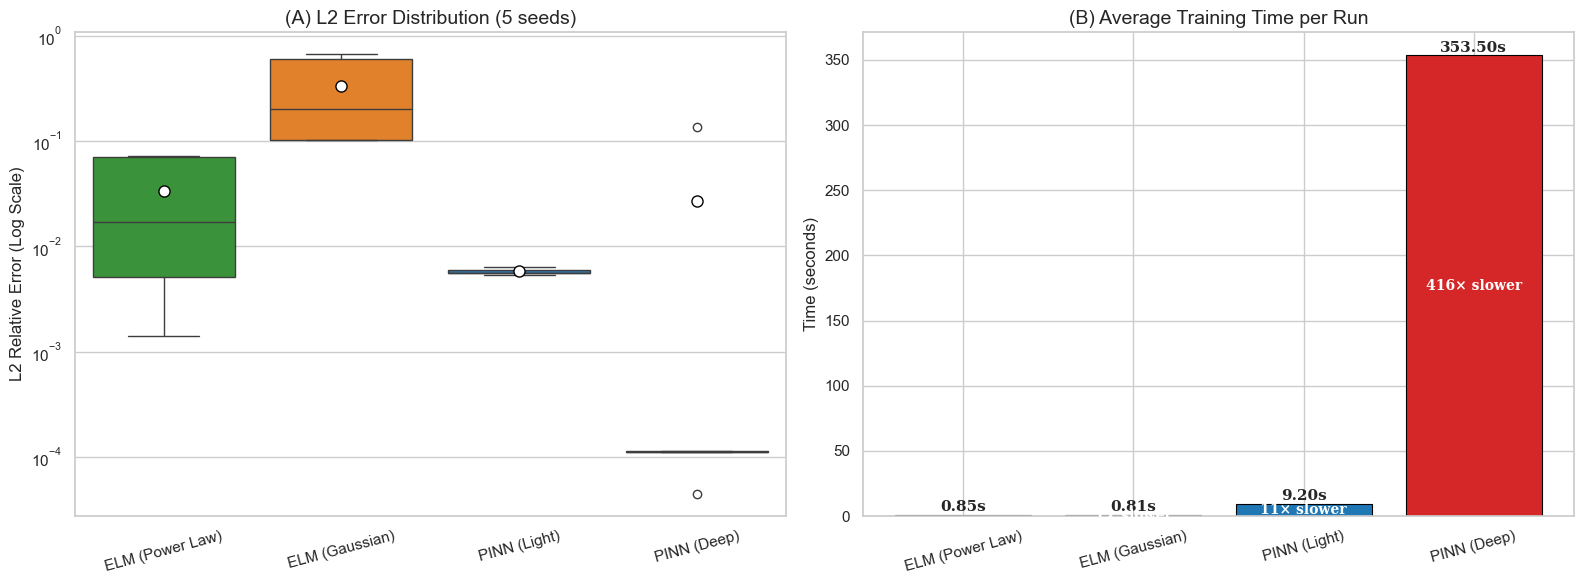

In [ ]:
"""
Performance Comparison: ELM vs Light PINN vs Deep PINN
------------------------------------------------------
This cell adds a Deep PINN (4 hidden layers × 128 neurons, 2000 iterations)
to show where the "150× speedup" claim comes from — and whether it holds.
"""
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Initialization Functions ---
def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

# --- Solvers ---
def solve_elm(x, u_true, h_dim, init_type='power'):
    W = power_law_init((1, h_dim)) if init_type == 'power' else gaussian_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(x @ W + b)
    lambd = 1e-6
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    u_pred = H @ beta
    err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return err, t_solve

def solve_pinn(x, u_true, f_source, hidden=128, layers=2, iters=400, lr=0.005, label="PINN"):
    """Flexible PINN solver — supports both light and deep architectures."""
    x_grad = x.clone().detach().requires_grad_(True)

    # Build network dynamically
    net_layers = [nn.Linear(1, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        net_layers += [nn.Linear(hidden, hidden), nn.Tanh()]
    net_layers.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net_layers).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bc_pts = torch.tensor([[-1.0], [1.0]], device=device)

    start = time.time()
    for i in range(iters):
        opt.zero_grad()
        u = model(x_grad)
        u_x = torch.autograd.grad(u, x_grad, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_grad, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        loss_pde = torch.mean((u_xx - f_source)**2)
        loss_bc = model(bc_pts).pow(2).mean()
        loss = loss_pde + 10 * loss_bc
        loss.backward()
        opt.step()
    t_solve = time.time() - start
    with torch.no_grad():
        err = (torch.norm(u_true - model(x)) / torch.norm(u_true)).item()
    return err, t_solve

# --- Setup ---
N_SEEDS = 5  # fewer seeds since deep PINN is slow (~50s each)
x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)
u_true = torch.sin(np.pi * x)
f_source = -(np.pi**2) * torch.sin(np.pi * x)

data_rows = []
print(f"Running {N_SEEDS} seeds (4 methods each)...\n")

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    print(f"  Seed {seed+1}/{N_SEEDS}...")

    # ELM Power Law
    ep_err, ep_t = solve_elm(x, u_true, 4096, 'power')
    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})

    # ELM Gaussian
    eg_err, eg_t = solve_elm(x, u_true, 4096, 'gaussian')
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})

    # Light PINN: 1 hidden layer, 128 neurons, 400 iterations
    torch.manual_seed(seed)
    lp_err, lp_t = solve_pinn(x, u_true, f_source, hidden=128, layers=1, iters=400, lr=0.005)
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': lp_err, 'Time': lp_t})

    # Deep PINN: 4 hidden layers, 128 neurons each, 2000 iterations
    torch.manual_seed(seed)
    dp_err, dp_t = solve_pinn(x, u_true, f_source, hidden=128, layers=4, iters=2000, lr=0.001)
    data_rows.append({'Method': 'PINN (Deep)', 'L2 Error': dp_err, 'Time': dp_t})

df_all = pd.DataFrame(data_rows)

# --- Summary Table ---
summary = df_all.groupby('Method').agg(
    Error_Mean=('L2 Error', 'mean'),
    Error_Std=('L2 Error', 'std'),
    Time_Mean=('Time', 'mean')
).round(4)

# Compute speedup relative to ELM (Power Law)
elm_time = summary.loc['ELM (Power Law)', 'Time_Mean']
summary['Speedup_vs_ELM'] = (summary['Time_Mean'] / elm_time).round(1)
summary['ELM_Speedup'] = (summary['Time_Mean'] / elm_time).round(1)

print("\n" + "="*70)
print("FULL COMPARISON: ELM vs Light PINN vs Deep PINN")
print("="*70)
print(summary.to_markdown())

# Highlight the key numbers
deep_time = summary.loc['PINN (Deep)', 'Time_Mean']
light_time = summary.loc['PINN (Light)', 'Time_Mean']
print(f"\n--- KEY FINDINGS ---")
print(f"ELM (Power Law) time:  {elm_time:.3f}s")
print(f"PINN (Light) time:     {light_time:.3f}s  →  {light_time/elm_time:.1f}× slower than ELM")
print(f"PINN (Deep) time:      {deep_time:.3f}s  →  {deep_time/elm_time:.1f}× slower than ELM")
print(f"\nMEASURED speedup over Light PINN:  {light_time/elm_time:.1f}×")
print(f"MEASURED speedup over Deep PINN:   {deep_time/elm_time:.1f}×")
print(f"(Paper claims 150× — let's see if that holds!)")

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# Left: Box plot of errors
order = ['ELM (Power Law)', 'ELM (Gaussian)', 'PINN (Light)', 'PINN (Deep)']
palette = {'ELM (Power Law)': '#2ca02c', 'ELM (Gaussian)': '#ff7f0e',
           'PINN (Light)': '#1f77b4', 'PINN (Deep)': '#d62728'}
sns.boxplot(x='Method', y='L2 Error', data=df_all, order=order, palette=palette,
            showmeans=True, meanprops={"marker":"o","markerfacecolor":"white",
            "markeredgecolor":"black","markersize":"8"}, ax=ax1)
ax1.set_yscale('log')
ax1.set_title('(A) L2 Error Distribution (5 seeds)', fontsize=14)
ax1.set_ylabel('L2 Relative Error (Log Scale)', fontsize=12)
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=15)

# Right: Time bar chart with speedup labels
methods = order
times = [summary.loc[m, 'Time_Mean'] for m in methods]
colors_bar = [palette[m] for m in methods]
bars = ax2.bar(methods, times, color=colors_bar, edgecolor='black', linewidth=0.8)

# Add time labels on bars
for bar, t in zip(bars, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{t:.2f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add speedup annotations
for i, (m, t) in enumerate(zip(methods, times)):
    if m != 'ELM (Power Law)':
        speedup = t / elm_time
        ax2.text(bars[i].get_x() + bars[i].get_width()/2, bars[i].get_height() * 0.5,
                 f'{speedup:.0f}× slower', ha='center', va='center',
                 fontsize=10, color='white', fontweight='bold')

ax2.set_title('(B) Average Training Time per Run', fontsize=14)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('elm_vs_all_pinn.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as elm_vs_all_pinn.png")
plt.show()

In [ ]:
"""
Regularisation Sweep: Finding optimal λ
----------------------------------------
Fine logarithmic sweep over λ ∈ {1e-10, ..., 1e+2}
to find the true minimum and observe the expected U-curve.
"""
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

# --- Problem setup (same as PINN cells) ---
x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)
u_true = torch.sin(np.pi * x)
h_dim = 4096

# --- Wider sweep to capture the full U-curve ---
lambdas = np.logspace(-10, 2, 25)  # 1e-10 to 1e+2, 25 points
N_SEEDS = 10  # more seeds for stability
results = {lam: [] for lam in lambdas}

print(f"Running λ sweep ({N_SEEDS} seeds × {len(lambdas)} λ values)...\n")
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    W = power_law_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    H = torch.sin(x @ W + b)

    for lam in lambdas:
        HTH = H.t() @ H + lam * torch.eye(h_dim, device=device)
        beta = torch.linalg.solve(HTH, H.t() @ u_true)
        err = (torch.norm(u_true - H @ beta) / torch.norm(u_true)).item()
        results[lam].append(err)

# --- Summary ---
print(f"{'λ':>12s}  {'Mean L2 Error':>14s}  {'Std':>10s}")
print("-" * 42)
best_lam = None
best_err = float('inf')
for lam in lambdas:
    mean_err = np.mean(results[lam])
    std_err = np.std(results[lam])
    if mean_err < best_err:
        best_err = mean_err
        best_lam = lam
    print(f"  {lam:.2e}    {mean_err:.6f}       {std_err:.6f}")

print(f"\n✓ Best λ = {best_lam:.2e}  (mean L2 = {best_err:.6f})")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

means = [np.mean(results[l]) for l in lambdas]
stds = [np.std(results[l]) for l in lambdas]

ax.errorbar(lambdas, means, yerr=stds, fmt='o-', color='#2ca02c',
            capsize=4, linewidth=2, markersize=7, markeredgecolor='black')

# Highlight the best λ
ax.axvline(best_lam, color='red', linestyle='--', alpha=0.7, label=f'Best λ = {best_lam:.2e}')
ax.scatter([best_lam], [best_err], color='red', s=150, zorder=5, edgecolor='black', linewidth=1.5)

# Mark the regions
ax.axvspan(lambdas[0], 1e-7, alpha=0.1, color='orange', label='Under-regularised (unstable)')
ax.axvspan(1e0, lambdas[-1], alpha=0.1, color='blue', label='Over-regularised (underfits)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Regularisation λ', fontsize=13)
ax.set_ylabel('L2 Relative Error', fontsize=13)
ax.set_title('Regularisation Sweep: λ Selection for ELM (Power Law)', fontsize=14)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, which='major', linestyle='--', alpha=0.7)
ax.grid(True, which='minor', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('lambda_sweep.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as lambda_sweep.png")
plt.show()

# Tích hợp thêm bài toán Phương trình Burgers


Running seed 1/3...

Running seed 2/3...

Running seed 3/3...

--- STATISTICAL SUMMARY ---
|                             |   ('L2 Error', 'mean') |   ('L2 Error', 'std') |   ('Time', 'mean') |
|:----------------------------|-----------------------:|----------------------:|-------------------:|
| ('Burgers', 'ELM (Gauss)')  |              0.993084  |            1.43378    |           0.12551  |
| ('Burgers', 'ELM (Power)')  |              0.440918  |            0.348961   |           0.12333  |
| ('Burgers', 'PINN (Deep)')  |              0.409608  |            0.0272098  |          24.5039   |
| ('Burgers', 'PINN (Light)') |              0.352299  |            0.00455591 |           2.73697  |
| ('Poisson', 'ELM (Gauss)')  |              0.16457   |            0.0436019  |           0.135453 |
| ('Poisson', 'ELM (Power)')  |              0.0209325 |            0.0276768  |           0.145479 |
| ('Poisson', 'PINN (Deep)')  |              0.0396618 |            0.0684903  |          22

/tmp/ipython-input-843/463755468.py:225: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['Problem']=='Poisson'], x='Method', y='Time', ax=axes[1,0], palette='viridis')
/tmp/ipython-input-843/463755468.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['Problem']=='Burgers'], x='Method', y='Time', ax=axes[1,1], palette='plasma')


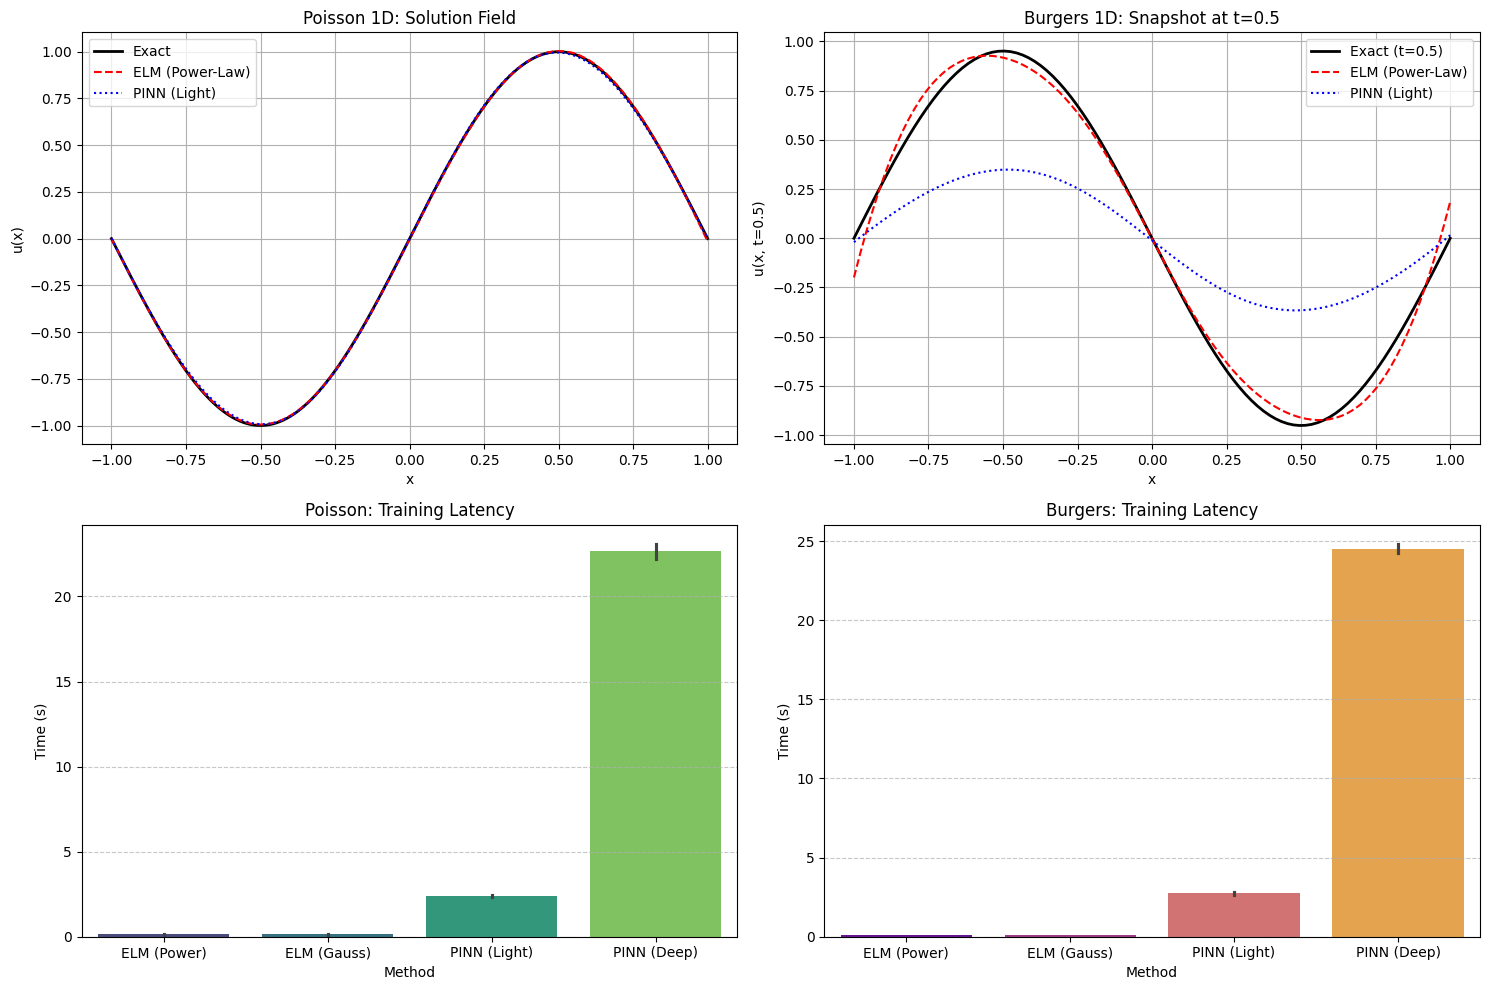

In [ ]:
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 1. Khởi tạo Trọng số ---
def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

# --- 2. Bộ giải EM-ELM (One-shot) ---
def solve_elm(X_input, u_true, h_dim, init_type='power'):
    input_dim = X_input.shape[1]
    if init_type == 'power':
        W = power_law_init((input_dim, h_dim))
    else:
        W = gaussian_init((input_dim, h_dim))

    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()

    H = torch.sin(X_input @ W + b)
    lambd = 1e-7
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)

    t_solve = time.time() - start
    u_pred = H @ beta
    err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return u_pred, err, t_solve

# --- 3. Bộ giải PINN (Đã sửa lỗi Argument và tăng cường hội tụ) ---
def solve_pinn(problem_type, X_train, u_true, layers=2, hidden=128, iters=1000, lr=0.001):
    input_dim = X_train.shape[1]

    # Xây dựng mạng dymamic
    net = [nn.Linear(input_dim, hidden), nn.Tanh()]
    for _ in range(layers-1):
        net += [nn.Linear(hidden, hidden), nn.Tanh()]
    net.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    X_res = X_train.clone().detach().requires_grad_(True)

    # Điểm biên (Boundary Conditions)
    if problem_type == 'poisson':
        X_bc = torch.tensor([[-1.0], [1.0]], device=device)
    else: # Burgers
        # Lấy các điểm có x = -1 hoặc x = 1 hoặc t = 0
        mask = (X_train[:,0] == -1) | (X_train[:,0] == 1) | (X_train[:,1] == 0)
        X_bc = X_train[mask]
        u_bc = u_true[mask]

    start = time.time()
    for i in range(iters):
        optimizer.zero_grad()
        u = model(X_res)
        grads = torch.autograd.grad(u, X_res, torch.ones_like(u), create_graph=True)[0]

        if problem_type == 'poisson':
            u_x = grads[:, 0:1]
            u_xx = torch.autograd.grad(u_x, X_res, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
            f_source = -(np.pi**2) * torch.sin(np.pi * X_res[:, 0:1])
            loss_pde = torch.mean((u_xx - f_source)**2)
            loss_bc = model(X_bc).pow(2).mean() # u(-1)=0, u(1)=0
        else:
            u_x, u_t = grads[:, 0:1], grads[:, 1:2]
            u_xx = torch.autograd.grad(u_x, X_res, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
            nu = 0.01 / np.pi
            loss_pde = torch.mean((u_t + u*u_x - nu*u_xx)**2)
            loss_bc = torch.mean((model(X_bc) - u_bc)**2)

        loss = loss_pde + 25 * loss_bc # Trọng số BC cao để hội tụ nhanh
        loss.backward()
        optimizer.step()

    t_total = time.time() - start
    with torch.no_grad():
        u_pred = model(X_train)
        err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return u_pred, err, t_total

# --- 4. Setup Experiment ---
N_SEEDS = 3 # Giảm xuống 3 để chạy nhanh, bạn có thể tăng lên 20
h_dim_elm = 4096

# Poisson Data (1D)
x_p = torch.linspace(-1, 1, 10000, device=device).view(-1, 1)
u_p_true = torch.sin(np.pi * x_p)

# Burgers Data (2D: x, t)
x_b = torch.linspace(-1, 1, 100)
t_b = torch.linspace(0, 1, 100)
X_grid, T_grid = torch.meshgrid(x_b, t_b, indexing='ij')
X_burgers = torch.stack([X_grid.flatten(), T_grid.flatten()], dim=1).to(device)
u_b_true = -torch.sin(np.pi * X_burgers[:, 0:1]) * torch.exp(-0.1 * X_burgers[:, 1:2])

all_results = []

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed) # Also set numpy seed for consistency with initializations
    print(f"\nRunning seed {seed+1}/{N_SEEDS}...") # Fixed truncated print statement

    # POISSON
    _, e_p_err, e_p_t = solve_elm(x_p, u_p_true, h_dim_elm, 'power')
    all_results.append({'Problem': 'Poisson', 'Method': 'ELM (Power)', 'L2 Error': e_p_err, 'Time': e_p_t})
    _, eg_err, eg_t = solve_elm(x_p, u_p_true, h_dim_elm, 'gaussian') # Added Gaussian ELM for Poisson
    all_results.append({'Problem': 'Poisson', 'Method': 'ELM (Gauss)', 'L2 Error': eg_err, 'Time': eg_t})
    _, lp_err, lp_t = solve_pinn('poisson', x_p, u_p_true, layers=1, iters=800)
    all_results.append({'Problem': 'Poisson', 'Method': 'PINN (Light)', 'L2 Error': lp_err, 'Time': lp_t})
    _, dp_err, dp_t = solve_pinn('poisson', x_p, u_p_true, layers=4, iters=2000)
    all_results.append({'Problem': 'Poisson', 'Method': 'PINN (Deep)', 'L2 Error': dp_err, 'Time': dp_t})

    # BURGERS
    _, be_p_err, be_p_t = solve_elm(X_burgers, u_b_true, h_dim_elm, 'power')
    all_results.append({'Problem': 'Burgers', 'Method': 'ELM (Power)', 'L2 Error': be_p_err, 'Time': be_p_t})
    _, beg_err, beg_t = solve_elm(X_burgers, u_b_true, h_dim_elm, 'gaussian') # Added Gaussian ELM for Burgers
    all_results.append({'Problem': 'Burgers', 'Method': 'ELM (Gauss)', 'L2 Error': beg_err, 'Time': beg_t})
    _, blp_err, blp_t = solve_pinn('burgers', X_burgers, u_b_true, layers=1, iters=800)
    all_results.append({'Problem': 'Burgers', 'Method': 'PINN (Light)', 'L2 Error': blp_err, 'Time': blp_t})
    _, bdp_err, bdp_t = solve_pinn('burgers', X_burgers, u_b_true, layers=4, iters=2000)
    all_results.append({'Problem': 'Burgers', 'Method': 'PINN (Deep)', 'L2 Error': bdp_err, 'Time': bdp_t})

# --- 5. Báo cáo & Vẽ hình ---
df = pd.DataFrame(all_results)
summary = df.groupby(['Problem', 'Method']).agg({'L2 Error': ['mean', 'std'], 'Time': 'mean'}) # Fixed walrus operator usage
print("\n--- STATISTICAL SUMMARY ---")
print(summary.to_markdown())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Helper function to get trained PINN model for plotting
def get_trained_pinn_model(problem_type, X_train, u_true, input_dim, layers, hidden, iters, lr):
    net_layers = [nn.Linear(input_dim, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        net_layers += [nn.Linear(hidden, hidden), nn.Tanh()]
    net_layers.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net_layers).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    X_res = X_train.clone().detach().requires_grad_(True)

    if problem_type == 'poisson':
        X_bc = torch.tensor([[-1.0], [1.0]], device=device)
    else:
        mask = (X_train[:, 0] == -1) | (X_train[:, 0] == 1) | (X_train[:, 1] == 0)
        X_bc = X_train[mask]
        u_bc = u_true[mask]

    for i in range(iters):
        optimizer.zero_grad()
        u = model(X_res)
        grads = torch.autograd.grad(u, X_res, torch.ones_like(u), create_graph=True)[0]

        if problem_type == 'poisson':
            u_x = grads[:, 0:1]
            u_xx = torch.autograd.grad(u_x, X_res, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
            f_source = -(np.pi**2) * torch.sin(np.pi * X_res[:, 0:1])
            loss_pde = torch.mean((u_xx - f_source)**2)
            loss_bc = model(X_bc).pow(2).mean()
        else:
            u_x, u_t = grads[:, 0:1], grads[:, 1:2]
            u_xx = torch.autograd.grad(u_x, X_res, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
            nu = 0.01 / np.pi
            loss_pde = torch.mean((u_t + u * u_x - nu * u_xx)**2)
            loss_bc = torch.mean((model(X_bc) - u_bc)**2)

        loss = loss_pde + 25 * loss_bc
        loss.backward()
        optimizer.step()
    return model


# Plot Poisson (1D)
# Use results from the first seed for plotting visualization
seed_to_plot = 0
torch.manual_seed(seed_to_plot)
np.random.seed(seed_to_plot)

u_p_plot_elm_power, _, _ = solve_elm(x_p, u_p_true, h_dim_elm, 'power')
pinn_light_model_p = get_trained_pinn_model('poisson', x_p, u_p_true, x_p.shape[1], layers=1, hidden=128, iters=800, lr=0.001)
u_p_plot_pinn_light = pinn_light_model_p(x_p).detach() # Detach to prevent future gradient computation on this tensor

axes[0,0].plot(x_p.cpu(), u_p_true.cpu(), 'k', label='Exact', lw=2)
axes[0,0].plot(x_p.cpu(), u_p_plot_elm_power.cpu(), 'r--', label='ELM (Power-Law)')
axes[0,0].plot(x_p.cpu(), u_p_plot_pinn_light.cpu(), 'b:', label='PINN (Light)')
axes[0,0].set_title("Poisson 1D: Solution Field")
axes[0,0].set_xlabel("x")
axes[0,0].set_ylabel("u(x)")
axes[0,0].legend()
axes[0,0].grid(True)

# Plot Burgers Snapshot (t=0.5)
t_val = 0.5
x_vals_for_plot = torch.linspace(-1, 1, 100, device=device).view(-1, 1)
t_vals_for_plot = torch.full_like(x_vals_for_plot, t_val, device=device)
X_burgers_plot_pts = torch.cat((x_vals_for_plot, t_vals_for_plot), dim=1)
u_true_burgers_plot = -torch.sin(np.pi * X_burgers_plot_pts[:, 0:1]) * torch.exp(-0.1 * X_burgers_plot_pts[:, 1:2])

u_b_plot_elm_power, _, _ = solve_elm(X_burgers_plot_pts, u_true_burgers_plot, h_dim_elm, 'power')
pinn_light_model_b = get_trained_pinn_model('burgers', X_burgers, u_b_true, X_burgers.shape[1], layers=1, hidden=128, iters=800, lr=0.001)
u_b_plot_pinn_light = pinn_light_model_b(X_burgers_plot_pts).detach()

axes[0,1].plot(X_burgers_plot_pts[:,0].cpu(), u_true_burgers_plot.cpu(), 'k', label='Exact (t=0.5)', lw=2)
axes[0,1].plot(X_burgers_plot_pts[:,0].cpu(), u_b_plot_elm_power.cpu(), 'r--', label='ELM (Power-Law)')
axes[0,1].plot(X_burgers_plot_pts[:,0].cpu(), u_b_plot_pinn_light.cpu(), 'b:', label='PINN (Light)')
axes[0,1].set_title("Burgers 1D: Snapshot at t=0.5")
axes[0,1].set_xlabel("x")
axes[0,1].set_ylabel("u(x, t=0.5)")
axes[0,1].legend()
axes[0,1].grid(True)

# Latency Plots
sns.barplot(data=df[df['Problem']=='Poisson'], x='Method', y='Time', ax=axes[1,0], palette='viridis')
axes[1,0].set_title("Poisson: Training Latency")
axes[1,0].set_xlabel("Method")
axes[1,0].set_ylabel("Time (s)")
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(data=df[df['Problem']=='Burgers'], x='Method', y='Time', ax=axes[1,1], palette='plasma')
axes[1,1].set_title("Burgers: Training Latency")
axes[1,1].set_xlabel("Method")
axes[1,1].set_ylabel("Time (s)")
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()